<a href="https://colab.research.google.com/github/mirzatairin/Environmental-Air-Quality-Assessment/blob/main/Environmental_Air_Quality_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# ============================================================
# AIR QUALITY ANALYSIS AND INSTANTANEOUS HOURLY AQI CALCULATION
# ============================================================

# This notebook:
# 1. Loads the air quality dataset
# 2. Cleans unnecessary columns
# 3. Converts pollutant concentrations into µg/m³
# 4. Removes rows with missing pollutant data
# 5. Calculates pollutant-wise AQI
# 6. Calculates overall AQI
# 7. Identifies the dominant pollutant
# 8. Displays the top 10 worst polluted hours


# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

df = pd.read_csv("/content/sample_data/air-quality-data-set.csv")

print("Original Dataset Shape:")
print(df.shape)

display(df.head())


# ============================================================
# STEP 3: REMOVE UNNECESSARY COLUMNS
# ============================================================

# Since the monitoring location remains constant,
# these columns are not required for AQI analysis.

columns_to_drop = [
    'location_id',
    'sensors_id',
    'location',
    'lat',
    'lon'
]

df = df.drop(columns=columns_to_drop)

print("\nDataset after dropping unnecessary columns:")
display(df.head())


# ============================================================
# STEP 4: CONVERT DATETIME COLUMN
# ============================================================

df['datetime'] = pd.to_datetime(df['datetime'])


# ============================================================
# STEP 5: PIVOT DATASET TO WIDE FORMAT
# ============================================================

# Convert pollutant rows into separate columns

df_wide = df.pivot_table(
    index='datetime',
    columns='parameter',
    values='value'
).reset_index()

print("\nWide-format dataset:")
display(df_wide.head())


# ============================================================
# STEP 6: CONVERT POLLUTANTS TO µg/m³
# ============================================================

# Conversion Formula:
# µg/m³ = (ppm × Molecular Weight × 1000) / 24.45

# Molecular weights:
# CO   = 28.01
# NO2  = 46.01
# O3   = 48.00
# SO2  = 64.07

co_ppm_to_ug_m3_factor = (28.01 * 1000) / 24.45
no2_ppm_to_ug_m3_factor = (46.01 * 1000) / 24.45
o3_ppm_to_ug_m3_factor = (48.00 * 1000) / 24.45
so2_ppm_to_ug_m3_factor = (64.07 * 1000) / 24.45


# Convert pollutants

if 'co' in df_wide.columns:
    df_wide['co_ug_m3'] = df_wide['co'] * co_ppm_to_ug_m3_factor

if 'no2' in df_wide.columns:
    df_wide['no2_ug_m3'] = df_wide['no2'] * no2_ppm_to_ug_m3_factor

if 'o3' in df_wide.columns:
    df_wide['o3_ug_m3'] = df_wide['o3'] * o3_ppm_to_ug_m3_factor

if 'so2' in df_wide.columns:
    df_wide['so2_ug_m3'] = df_wide['so2'] * so2_ppm_to_ug_m3_factor


print("\nDataset after unit conversion:")
display(
    df_wide[
        [
            'datetime',
            'co_ug_m3',
            'no2_ug_m3',
            'o3_ug_m3',
            'so2_ug_m3',
            'pm10',
            'pm25'
        ]
    ].head()
)


# ============================================================
# STEP 7: KEEP ONLY REQUIRED COLUMNS
# ============================================================

columns_to_keep = [
    'datetime',
    'co_ug_m3',
    'no2_ug_m3',
    'o3_ug_m3',
    'so2_ug_m3',
    'pm10',
    'pm25'
]

df_cleaned = df_wide[columns_to_keep].copy()

print("\nCleaned dataset:")
display(df_cleaned.head())


# ============================================================
# STEP 8: REMOVE ROWS WITH MISSING VALUES
# ============================================================

air_quality_cols = [
    'co_ug_m3',
    'no2_ug_m3',
    'o3_ug_m3',
    'so2_ug_m3',
    'pm10',
    'pm25'
]

df_cleaned = df_cleaned.dropna(subset=air_quality_cols)

print("\nDataset after removing missing values:")
print(df_cleaned.shape)

display(df_cleaned.head())


# ============================================================
# STEP 9: AQI CALCULATION FUNCTION
# ============================================================

def calculate_aqi_for_pollutant(C, breakpoints_C, breakpoints_I):
    """
    Calculate AQI using linear interpolation.

    Parameters:
        C               : Pollutant concentration
        breakpoints_C   : Concentration breakpoints
        breakpoints_I   : AQI breakpoints

    Returns:
        AQI value
    """

    if np.isnan(C):
        return np.nan

    for i in range(len(breakpoints_C) - 1):

        C_low = breakpoints_C[i]
        C_high = breakpoints_C[i + 1]

        I_low = breakpoints_I[i]
        I_high = breakpoints_I[i + 1]

        if C_low <= C <= C_high:

            return (
                ((I_high - I_low) / (C_high - C_low))
                * (C - C_low)
                + I_low
            )

    # Cap values outside range

    if C > breakpoints_C[-1]:
        return breakpoints_I[-1]

    if C < breakpoints_C[0]:
        return breakpoints_I[0]

    return np.nan


# ============================================================
# STEP 10: DEFINE AQI BREAKPOINTS
# ============================================================

# ---------------------------
# PM2.5
# ---------------------------

pm25_breakpoints_C = [
    0.0, 12.0, 35.4, 55.4,
    150.4, 250.4, 500.4
]

pm25_breakpoints_I = [
    0, 50, 100, 150,
    200, 300, 500
]

# ---------------------------
# PM10
# ---------------------------

pm10_breakpoints_C = [
    0, 54, 154, 254,
    354, 424, 504
]

pm10_breakpoints_I = [
    0, 50, 100, 150,
    200, 300, 500
]

# ---------------------------
# CO
# ---------------------------

co_breakpoints_C_ppm = [
    0.0, 4.4, 9.4, 12.4,
    15.4, 30.4, 40.4
]

co_breakpoints_C = [
    c * co_ppm_to_ug_m3_factor
    for c in co_breakpoints_C_ppm
]

co_breakpoints_I = [
    0, 50, 100, 150,
    200, 300, 500
]

# ---------------------------
# O3
# ---------------------------

o3_breakpoints_C_ppm = [
    0.000, 0.054, 0.070,
    0.085, 0.105, 0.200, 0.400
]

o3_breakpoints_C = [
    c * o3_ppm_to_ug_m3_factor
    for c in o3_breakpoints_C_ppm
]

o3_breakpoints_I = [
    0, 50, 100, 150,
    200, 300, 500
]

# ---------------------------
# NO2
# ---------------------------

no2_ppb_to_ug_m3_factor = 1.881799591002045

no2_breakpoints_C_ppb = [
    0, 53, 100, 360,
    649, 1249, 2049
]

no2_breakpoints_C = [
    c * no2_ppb_to_ug_m3_factor
    for c in no2_breakpoints_C_ppb
]

no2_breakpoints_I = [
    0, 50, 100, 150,
    200, 300, 500
]

# ---------------------------
# SO2
# ---------------------------

so2_ppb_to_ug_m3_factor = 2.620449897750511

so2_breakpoints_C_ppb = [
    0, 35, 75, 185,
    304, 604, 1004
]

so2_breakpoints_C = [
    c * so2_ppb_to_ug_m3_factor
    for c in so2_breakpoints_C_ppb
]

so2_breakpoints_I = [
    0, 50, 100, 150,
    200, 300, 500
]


# ============================================================
# STEP 11: CALCULATE POLLUTANT-WISE AQI
# ============================================================

df_cleaned['aqi_pm25'] = df_cleaned['pm25'].apply(
    lambda x: calculate_aqi_for_pollutant(
        x,
        pm25_breakpoints_C,
        pm25_breakpoints_I
    )
)

df_cleaned['aqi_pm10'] = df_cleaned['pm10'].apply(
    lambda x: calculate_aqi_for_pollutant(
        x,
        pm10_breakpoints_C,
        pm10_breakpoints_I
    )
)

df_cleaned['aqi_co'] = df_cleaned['co_ug_m3'].apply(
    lambda x: calculate_aqi_for_pollutant(
        x,
        co_breakpoints_C,
        co_breakpoints_I
    )
)

df_cleaned['aqi_o3'] = df_cleaned['o3_ug_m3'].apply(
    lambda x: calculate_aqi_for_pollutant(
        x,
        o3_breakpoints_C,
        o3_breakpoints_I
    )
)

df_cleaned['aqi_no2'] = df_cleaned['no2_ug_m3'].apply(
    lambda x: calculate_aqi_for_pollutant(
        x,
        no2_breakpoints_C,
        no2_breakpoints_I
    )
)

df_cleaned['aqi_so2'] = df_cleaned['so2_ug_m3'].apply(
    lambda x: calculate_aqi_for_pollutant(
        x,
        so2_breakpoints_C,
        so2_breakpoints_I
    )
)


# ============================================================
# STEP 12: CALCULATE OVERALL AQI
# ============================================================

aqi_columns = [
    'aqi_pm25',
    'aqi_pm10',
    'aqi_co',
    'aqi_o3',
    'aqi_no2',
    'aqi_so2'
]

# Overall AQI = maximum AQI among pollutants

df_cleaned['AQI'] = df_cleaned[aqi_columns].max(axis=1)


# ============================================================
# STEP 13: IDENTIFY DOMINANT POLLUTANT
# ============================================================

df_cleaned['dominant_pollutant'] = (
    df_cleaned[aqi_columns]
    .idxmax(axis=1)
    .str.replace('aqi_', '')
)

# Round AQI values for readability

df_cleaned['AQI'] = df_cleaned['AQI'].round(2)


print("\nDataset with AQI values:")
display(
    df_cleaned[
        ['datetime'] + aqi_columns + ['AQI', 'dominant_pollutant']
    ].head()
)


# ============================================================
# STEP 14: FIND TOP 10 WORST POLLUTED HOURS
# ============================================================

top_10_aqi_hours = (
    df_cleaned
    .sort_values(by='AQI', ascending=False)
    .head(10)
)

print("\nTop 10 Worst Polluted Hours:")

display(
    top_10_aqi_hours[
        [
            'datetime',
            'AQI',
            'dominant_pollutant'
        ]
    ]
)


# ============================================================
# STEP 15: OPTIONAL - SAVE RESULTS
# ============================================================

top_10_aqi_hours.to_csv(
    "top_10_worst_polluted_hours.csv",
    index=False
)

print("\nTop 10 polluted hours saved successfully.")

Original Dataset Shape:
(4284, 9)


,location_id,sensors_id,location,datetime,lat,lon,parameter,units,value
0,2178,3919,Del Norte-2178,2025-12-01T01:00:00-07:00,35.1353,-106.584702,pm10,µg/m³,31.0
1,2178,3919,Del Norte-2178,2025-12-01T02:00:00-07:00,35.1353,-106.584702,pm10,µg/m³,30.0
2,2178,3919,Del Norte-2178,2025-12-01T03:00:00-07:00,35.1353,-106.584702,pm10,µg/m³,20.0
3,2178,3919,Del Norte-2178,2025-12-01T04:00:00-07:00,35.1353,-106.584702,pm10,µg/m³,6.0
4,2178,3919,Del Norte-2178,2025-12-01T05:00:00-07:00,35.1353,-106.584702,pm10,µg/m³,4.0



Dataset after dropping unnecessary columns:


,datetime,parameter,units,value
0,2025-12-01T01:00:00-07:00,pm10,µg/m³,31.0
1,2025-12-01T02:00:00-07:00,pm10,µg/m³,30.0
2,2025-12-01T03:00:00-07:00,pm10,µg/m³,20.0
3,2025-12-01T04:00:00-07:00,pm10,µg/m³,6.0
4,2025-12-01T05:00:00-07:00,pm10,µg/m³,4.0



Wide-format dataset:


...


Dataset with AQI values:


parameter,datetime,aqi_pm25,aqi_pm10,aqi_co,aqi_o3,aqi_no2,aqi_so2,AQI,dominant_pollutant
0,2025-12-01 01:00:00-07:00,24.583333,28.703704,1.136364,28.703704,5.660377,0.571429,28.70,o3
1,2025-12-01 02:00:00-07:00,25.000000,27.777778,1.136364,27.777778,6.603774,0.571429,27.78,pm10
2,2025-12-01 03:00:00-07:00,15.000000,18.518519,1.136364,34.259259,6.603774,0.428571,34.26,o3
3,2025-12-01 04:00:00-07:00,3.333333,5.555556,1.136364,43.518519,3.773585,0.428571,43.52,o3
4,2025-12-01 05:00:00-07:00,3.750000,3.703704,1.136364,39.814815,6.603774,0.428571,39.81,o3



Top 10 Worst Polluted Hours:


parameter,datetime,AQI,dominant_pollutant
738,2025-12-31 22:00:00-07:00,111.25,pm25
509,2025-12-22 09:00:00-07:00,106.35,no2
510,2025-12-22 10:00:00-07:00,105.96,no2
739,2025-12-31 23:00:00-07:00,104.75,pm25
176,2025-12-08 09:00:00-07:00,104.62,no2
391,2025-12-17 08:00:00-07:00,104.62,no2
442,2025-12-19 11:00:00-07:00,103.46,no2
175,2025-12-08 08:00:00-07:00,103.27,no2
392,2025-12-17 09:00:00-07:00,101.54,no2
224,2025-12-10 09:00:00-07:00,100.38,no2



Top 10 polluted hours saved successfully.


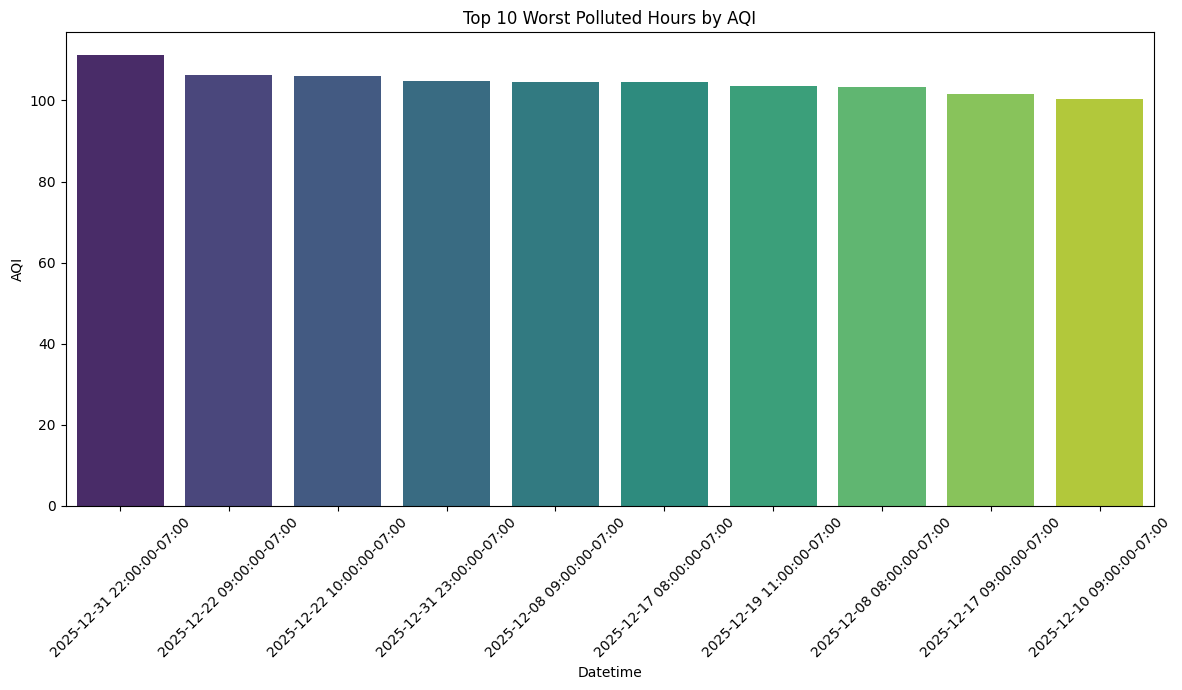

In [17]:
# ============================================================
# BAR CHART OF TOP 10 WORST AQI HOURS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(12, 7))

# Plot bar chart
sns.barplot(x='datetime', y='AQI', data=top_10_aqi_hours, hue="datetime", palette='viridis')

# Labels and title
plt.xlabel("Datetime")
plt.ylabel("AQI")
plt.title("Top 10 Worst Polluted Hours by AQI")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Improve layout
plt.tight_layout()

# Show plot
plt.show()